In [1]:
import h5py
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cell_data import calculate_purity,cluster_matrix_hierarchical
import behave_ana
from scipy.stats import zscore,entropy
import matplotlib.gridspec as gridspec
from scipy.stats import sem  # 标准误差
from scipy.cluster.hierarchy import dendrogram,fcluster
from scipy.ndimage import uniform_filter1d
try:
    if __IPYTHON__:
        get_ipython().run_line_magic('load_ext', 'autoreload')
        get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
from pathlib import Path
pkl_dir = '/home/zyyk78/HDD/zyyk78/Stage4/C02'
h5_root_dir = '/home/zyyk78/HDD/zyyk78/Stage4/Miniscope/C02'
beh_video_dir = '/home/zyyk78/HDD/zyyk78/Stage4/video/CamT'

# ========== 构建日期到pkl的映射 ==========
pkl_dict = {}
for pkl_file in Path(pkl_dir).glob("*.pkl"):
    date_key = pkl_file.name[:8]
    pkl_dict[date_key] = str(pkl_file)

# ========== 匹配 pkl 和 hdf ==========
hdf_dict = {}
for h5_file in Path(h5_root_dir).rglob("*.hdf5"):
    folder_date = h5_file.relative_to(h5_root_dir).parts[0].replace("_", "")
    if folder_date in pkl_dict:
        hdf_dict[folder_date] = str(h5_file)

# ========== 匹配 pkl 和 csv ==========
csv_dict = {}
for pkl_file in Path(pkl_dir).glob("*.pkl"):
    evt_file = pkl_file.with_suffix('.evt')
    if not evt_file.exists():
        continue
    evt_mtime = evt_file.stat().st_mtime
    
    for mp4_file in Path(beh_video_dir).rglob("*.mp4"):
        if abs(mp4_file.stat().st_mtime - evt_mtime) < 10:  # 允许10秒误差
            csv_file = mp4_file.with_suffix('.csv')
            if csv_file.exists():
                csv_dict[pkl_file.name[:8]] = str(csv_file)
            break

# ========== 统一匹配结果 (pkl, hdf, csv) ==========
result_pairs = []
for date_key, pkl_path in pkl_dict.items():
    hdf_path = hdf_dict.get(date_key, None)
    csv_path = csv_dict.get(date_key, None)
    if hdf_path:  # 只保留同时有 pkl 和 hdf 的
        result_pairs.append((pkl_path, hdf_path, csv_path))

# 输出结果
for idx, (pkl_path, h5_path, csv_path) in enumerate(result_pairs):
    csv_str = csv_path if csv_path else "None"
    print(f'ID:{idx} PKL: {pkl_path} HDF5: {h5_path} CSV: {csv_str}')

ID:0 PKL: /home/zyyk78/HDD/zyyk78/Stage4/C02/20251212_T7F_00.pkl HDF5: /home/zyyk78/HDD/zyyk78/Stage4/Miniscope/C02/2025_12_12/15_49_17/miniscope1/0_20260105_043006_corr_20260117_161200_results.hdf5 CSV: /home/zyyk78/HDD/zyyk78/Stage4/video/CamT/Cam3_2025-12-12_15-40-37_2.csv
ID:1 PKL: /home/zyyk78/HDD/zyyk78/Stage4/C02/20251202_P7F_00.pkl HDF5: /home/zyyk78/HDD/zyyk78/Stage4/Miniscope/C02/2025_12_02/15_31_53/miniscope1/0_20260105_014231_corr_20260117_100721_results.hdf5 CSV: /home/zyyk78/HDD/zyyk78/Stage4/video/CamT/Cam3_2025-12-02_15-25-24_2.csv
ID:2 PKL: /home/zyyk78/HDD/zyyk78/Stage4/C02/20251227_T7F_00.pkl HDF5: /home/zyyk78/HDD/zyyk78/Stage4/Miniscope/C02/2025_12_27/15_42_51/miniscope1/0_20260105_033819_corr_20260118_000202_results.hdf5 CSV: /home/zyyk78/HDD/zyyk78/Stage4/video/CamT/Cam3_2025-12-27_15-31-08_0.csv
ID:3 PKL: /home/zyyk78/HDD/zyyk78/Stage4/C02/20251223_T7F_00.pkl HDF5: /home/zyyk78/HDD/zyyk78/Stage4/Miniscope/C02/2025_12_23/15_21_51/miniscope1/0_20260105_023704_corr

In [38]:
result_pairs=[('/home/zyyk78/HDD/zyyk78/Stage3/A05/20250325_00.pkl',
               '/home/zyyk78/todo/MS__2025-03-25T17_56_52_20250917_171643_results_refine.hdf5',
               '/home/zyyk78/todo/Cam3_2025-03-25_17-53-52_4.csv')]


In [39]:
ID = 0
mode = 'C'
smooth_w = 0.5
pkl_path, hdf_path, csv_path = result_pairs[ID]

with h5py.File(hdf_path, 'r') as hdf_file:
    fr = hdf_file['params']['data']['fr'][()]
    fr = 25  ## tiaoshi
    C = np.array(hdf_file['estimates']['C'])
    C_z = zscore(C, axis=1)
    S = np.array(hdf_file['estimates']['S'])
    S_sm = uniform_filter1d(S, size = int(smooth_w*fr), axis=1)
    S_z = zscore(S_sm, axis=1)
    
with open(pkl_path,"rb") as pkl_f:
        Event=pickle.load(pkl_f)   

# 加载 CSV 文件并进行二次插值
csv_data = None
pos_frames = None
pos_centroids = None
pos_interp = None  # T*2 的位置坐标数组
pos_fps = None  # CSV 的帧率
if csv_path:
    # 读取前两行获取总时长和总帧数
    with open(csv_path, 'r') as f:
        first_line = f.readline().strip()
        second_line = f.readline().strip()
    total_duration = float(first_line.split(':')[1].split()[0].strip())  # 秒
    total_frames = int(second_line.split(':')[1].strip())
    pos_fps = total_frames / total_duration
    
    print(f'CSV total duration: {total_duration} s')
    print(f'CSV total frames: {total_frames}')
    print(f'CSV fps: {pos_fps}')
    
    # 读取CSV数据（跳过前两行备注）
    csv_data = pd.read_csv(csv_path, skiprows=2)
    pos_frames = csv_data['frame'].values
    pos_centroids = csv_data[['centroid_x', 'centroid_y']].values
    
    # 去除 NaN 值
    valid_mask = ~np.isnan(pos_centroids).any(axis=1)
    pos_frames_clean = pos_frames[valid_mask]
    pos_centroids_clean = pos_centroids[valid_mask]
    print(f'Valid points: {len(pos_frames_clean)} / {len(pos_frames)}')
    
    # 二次插值到完整帧数
    from scipy.interpolate import interp1d
    
    # 对 x 和 y 分别进行二次插值
    interp_x = interp1d(pos_frames_clean, pos_centroids_clean[:, 0], kind='quadratic', 
                        bounds_error=False, fill_value='extrapolate')
    interp_y = interp1d(pos_frames_clean, pos_centroids_clean[:, 1], kind='quadratic', 
                        bounds_error=False, fill_value='extrapolate')
    
    all_frames = np.arange(total_frames)
    pos_interp = np.column_stack([interp_x(all_frames), interp_y(all_frames)])
    print(f'pos_interp shape: {pos_interp.shape}')
    print(f'NaN in pos_interp: {np.isnan(pos_interp).sum()}')
    print(f'Sample pos_interp[0]: {pos_interp[0]}')

if mode == 'S':
    signal = S_z
    print('钙信号模式')
elif mode == 'C':
    signal = C_z
    print('反卷积模式')
signal = np.repeat(signal, 2, axis=1)  ###tiaoshi

CSV total duration: 2934.19 s
CSV total frames: 87387
CSV fps: 29.78232493464977
Valid points: 7774 / 7945
pos_interp shape: (87387, 2)
NaN in pos_interp: 0
Sample pos_interp[0]: [218.98 214.18]
反卷积模式


In [40]:
from cell_data import match_segments
keep_list=['MinS','MinT','SlnL','SlnR','ROmL','ROmR','LickL','LickR']
ignore_list=[i for i in list(Event.keys()) if i not in keep_list]
long_event=['Blackhole','MinS','MinT']
eve_list=behave_ana.sort_events(Event,ignore_list=ignore_list,long_event=long_event)
new_eve_list = []
in_MinT = False

for timestamp, event in eve_list:
    if event == 'MinT_S':
        in_MinT = True
        continue  # 跳过 MinT_S
    elif event == 'MinT_E':
        in_MinT = False
        continue  # 跳过 MinT_E
    elif event in ['MinS_S', 'MinS_E']:
        if not in_MinT:  # 不在 MinT 期间内，移除
            continue
    new_eve_list.append((timestamp, event))

eve_list = new_eve_list
eve_list,signal=match_segments(eve_list,signal)

检测完成：共发现 1 段记录。

段落         | 开始时间            | 结束时间            | 持续帧数      
------------------------------------------------------------
Segment 1  | 8513761         | 126114154       | 57952     
Len of MS Record:  57950
Dropped frams:  2
Most like seq is:  1
已随机插入 2 帧用以补全丢帧


Start timestamp: 8513761 -> 170.28 s
End timestamp: 126114154 -> 2522.28 s
Duration: 2352.01 s
Signal frames: 57952
Pos fps: 29.78232493464977
Start -> Pos frame: 5071
End -> Pos frame: 75119
Pos segment before resample: (70048, 2)
Pos segment resampled: (57952, 2)
Computed place fields for 512 neurons
Sample scores for first 5 neurons:
  Neuron 0: SI=0.216, Sparsity=0.295, Coherence=0.474, Score=0.291
  Neuron 1: SI=0.275, Sparsity=0.338, Coherence=0.442, Score=0.327
  Neuron 2: SI=0.239, Sparsity=0.273, Coherence=0.504, Score=0.302
  Neuron 3: SI=0.363, Sparsity=0.401, Coherence=0.435, Score=0.389
  Neuron 4: SI=0.490, Sparsity=0.468, Coherence=0.641, Score=0.514


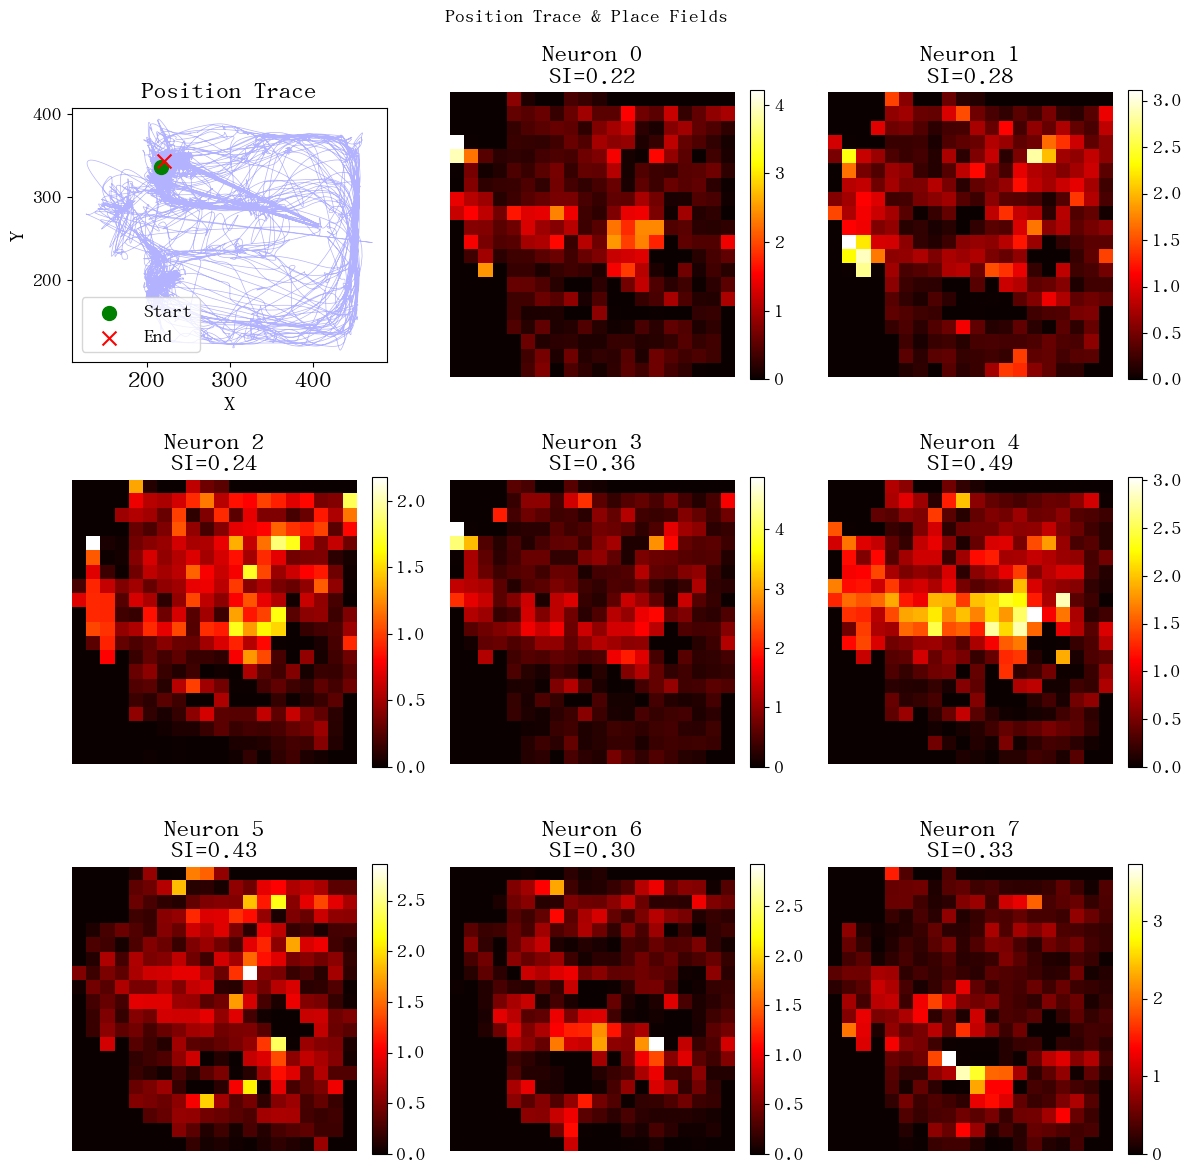

In [41]:
# ========== Place Field 计算 ==========
# 先计算 pos_segment
start_ts = eve_list[0][0]   # 起始时间戳
end_ts = eve_list[-1][0]    # 结束时间戳
start_time_sec = start_ts / 50000  # 转换为秒
end_time_sec = end_ts / 50000

print(f'Start timestamp: {start_ts} -> {start_time_sec:.2f} s')
print(f'End timestamp: {end_ts} -> {end_time_sec:.2f} s')
print(f'Duration: {end_time_sec - start_time_sec:.2f} s')
print(f'Signal frames: {signal.shape[1]}')

# 使用 pos 的 fps 计算对应的帧
if pos_interp is not None and pos_fps is not None:
    start_pos_frame = int(start_time_sec * pos_fps)
    end_pos_frame = int(end_time_sec * pos_fps)
    
    print(f'Pos fps: {pos_fps}')
    print(f'Start -> Pos frame: {start_pos_frame}')
    print(f'End -> Pos frame: {end_pos_frame}')
    
    # 截取对应区间的位置坐标
    pos_segment = pos_interp[start_pos_frame:end_pos_frame]
    print(f'Pos segment before resample: {pos_segment.shape}')
    
    # 插值到与 hdf (signal) 相同的帧数
    from scipy.interpolate import interp1d
    
    signal_frames = signal.shape[1]
    orig_frames = np.arange(len(pos_segment))
    target_frames = np.linspace(0, len(pos_segment) - 1, signal_frames)
    
    interp_x = interp1d(orig_frames, pos_segment[:, 0], kind='linear', 
                        bounds_error=False, fill_value='extrapolate')
    interp_y = interp1d(orig_frames, pos_segment[:, 1], kind='linear', 
                        bounds_error=False, fill_value='extrapolate')
    
    pos_segment = np.column_stack([interp_x(target_frames), interp_y(target_frames)])
    print(f'Pos segment resampled: {pos_segment.shape}')
else:
    print('No pos_interp or pos_fps available')

# 计算 Place Field
from cell_data import compute_place_fields

place_fields, place_scores = compute_place_fields(signal, pos_segment, chunknum=20, smooth_sigma=.3)

num_neurons = signal.shape[0]
print(f'Computed place fields for {num_neurons} neurons')
print(f'Sample scores for first 5 neurons:')
for i in range(min(5, num_neurons)):
    print(f'  Neuron {i}: SI={place_fields[i]["spatial_info"]:.3f}, '
          f'Sparsity={place_fields[i]["sparsity"]:.3f}, '
          f'Coherence={place_fields[i]["coherence"]:.3f}, '
          f'Score={place_scores[i]:.3f}')

# ========== Place Field 可视化 ==========
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

# 1号位置画轨迹
ax_trace = axes[0]
ax_trace.plot(pos_segment[:, 0], pos_segment[:, 1], 'b-', alpha=0.3, linewidth=0.5)
ax_trace.scatter(pos_segment[0, 0], pos_segment[0, 1], c='green', s=100, marker='o', label='Start', zorder=5)
ax_trace.scatter(pos_segment[-1, 0], pos_segment[-1, 1], c='red', s=100, marker='x', label='End', zorder=5)
ax_trace.set_title('Position Trace')
ax_trace.legend()
ax_trace.set_xlabel('X')
ax_trace.set_ylabel('Y')
ax_trace.set_aspect('equal')

# 其余位置画 place field (2-9号)
for i in range(1, 9):
    ax = axes[i]
    neuron_id = i - 1  # 神经元索引（0开始）
    if neuron_id >= num_neurons:
        ax.axis('off')
        continue
        
    rate_map = place_fields[neuron_id]['rate_map']
    
    im = ax.imshow(rate_map, cmap='hot', origin='lower')
    ax.set_title(f'Neuron {neuron_id}\nSI={place_fields[neuron_id]["spatial_info"]:.2f}')
    ax.axis('off')
    
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Position Trace & Place Fields', fontsize=14)
plt.tight_layout()
plt.show()

Running 5-fold cross-validation (FULL DECODER)...
  Fold 1/5 completed
  Fold 2/5 completed
  Fold 3/5 completed
  Fold 4/5 completed
  Fold 5/5 completed

完全解码器 RMSE (所有细胞): 48.4575 ± 60.2725

Running Leave-One-Out analysis...
Positive cells: 244, Negative cells: 268
Fold baseline RMSE: 47.3612


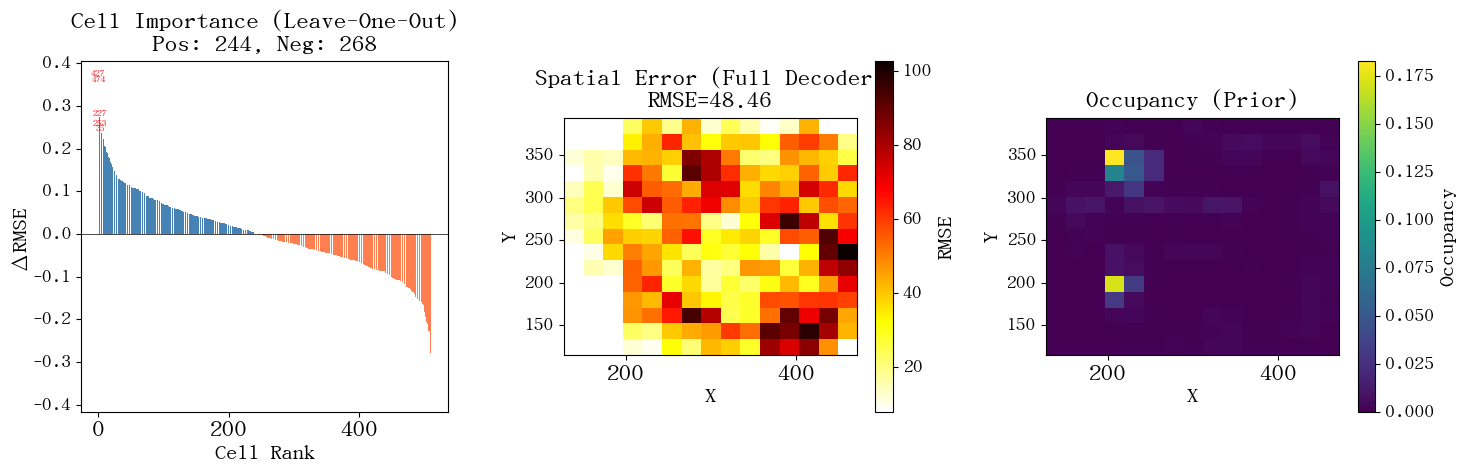


完全解码器分析结果:
  完全解码器 RMSE (所有 512 细胞): 48.4575 ± 60.2725
  Fold baseline RMSE: 47.3612


In [43]:
# ========== 贝叶斯位置解码器 + 完全解码器 + 细胞重要性分析 ==========
from sklearn.model_selection import KFold
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')

# 准备数据
X = signal.T  # (T, nCell)
y = pos_segment  # (T, 2)
n_bins = 15
x_min, x_max = y[:, 0].min(), y[:, 0].max()
y_min, y_max = y[:, 1].min(), y[:, 1].max()

# 空间分箱
x_bins = np.linspace(x_min, x_max, n_bins + 1)
y_bins = np.linspace(y_min, y_max, n_bins + 1)
x_bin_idx = np.clip(np.digitize(y[:, 0], x_bins) - 1, 0, n_bins - 1)
y_bin_idx = np.clip(np.digitize(y[:, 1], y_bins) - 1, 0, n_bins - 1)
pos_bin_idx = x_bin_idx * n_bins + y_bin_idx
n_pos_bins = n_bins * n_bins

# 位置先验概率
prior = np.bincount(pos_bin_idx, minlength=n_pos_bins).astype(float)
prior /= prior.sum()

# 贝叶斯解码函数
def bayesian_decode(X_test, lambda_matrix, prior):
    n_pos = lambda_matrix.shape[0]
    log_prior = np.log(prior + 1e-10)
    log_lambda = np.log(lambda_matrix + 1e-10)
    log_likelihood = X_test @ log_lambda.T - lambda_matrix.sum(axis=1)
    log_posterior = log_likelihood + log_prior
    log_posterior_max = log_posterior.max(axis=1, keepdims=True)
    posterior = np.exp(log_posterior - log_posterior_max)
    posterior /= posterior.sum(axis=1, keepdims=True)
    x_coords = (np.arange(n_pos) // n_bins) * (x_max - x_min) / n_bins + (x_max - x_min) / (2 * n_bins) + x_min
    y_coords = (np.arange(n_pos) % n_bins) * (y_max - y_min) / n_bins + (y_max - y_min) / (2 * n_bins) + y_min
    expected_x = posterior @ x_coords
    expected_y = posterior @ y_coords
    return np.stack([expected_x, expected_y], axis=1)

def train_and_decode(X_train, X_test, train_pos_bins, prior):
    """训练贝叶斯解码器并在测试集上解码"""
    train_prior = np.bincount(train_pos_bins, minlength=n_pos_bins).astype(float)
    train_prior /= train_prior.sum()
    train_lambda = np.zeros((n_pos_bins, X_train.shape[1]))
    for b in range(n_pos_bins):
        mask = train_pos_bins == b
        if mask.sum() > 0:
            train_lambda[b] = X_train[mask].mean(axis=0)
    train_lambda = np.clip(train_lambda, 1e-10, None)
    return bayesian_decode(X_test, train_lambda, train_prior)

# ========== 5折交叉验证完全解码器 ==========
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_full = np.zeros_like(y)

print("Running 5-fold cross-validation (FULL DECODER)...")
for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    train_pos_bins = pos_bin_idx[train_idx]
    y_pred_full[test_idx] = train_and_decode(X_train, X_test, train_pos_bins, prior)
    print(f"  Fold {fold+1}/5 completed")

euclidean_error_full = np.sqrt(np.sum((y_pred_full - y) ** 2, axis=1))
full_rmse = euclidean_error_full.mean()
full_std = euclidean_error_full.std()
print(f"\n完全解码器 RMSE (所有细胞): {full_rmse:.4f} ± {full_std:.4f}")

# ========== 细胞重要性分析 (Leave-One-Out，在同一 fold 内计算) ==========
def evaluate_cell_knockout(cell_idx, X_train, train_pos_bins, X_test, y_test, prior):
    """去除一个细胞后的解码误差"""
    other_cells = [c for c in range(X_train.shape[1]) if c != cell_idx]
    train_lambda = np.zeros((n_pos_bins, len(other_cells)))
    for b in range(n_pos_bins):
        mask = train_pos_bins == b
        if mask.sum() > 0:
            train_lambda[b] = X_train[mask][:, other_cells].mean(axis=0)
    train_lambda = np.clip(train_lambda, 1e-10, None)
    y_pred = bayesian_decode(X_test[:, other_cells], train_lambda, prior)
    return np.sqrt(np.sum((y_pred - y_test) ** 2, axis=1)).mean()

print("\nRunning Leave-One-Out analysis...")

# 在第一个 fold 上计算细胞重要性
train_idx, test_idx = list(cv.split(X))[0]
X_train_fold, X_test_fold = X[train_idx], X[test_idx]
y_test_fold = y[test_idx]
train_pos_bins_fold = pos_bin_idx[train_idx]
train_prior_fold = np.bincount(train_pos_bins_fold, minlength=n_pos_bins).astype(float)
train_prior_fold /= train_prior_fold.sum()
nCell = X.shape[1]

errors_loo = Parallel(n_jobs=-1, verbose=0)(
    delayed(evaluate_cell_knockout)(i, X_train_fold, train_pos_bins_fold, X_test_fold, y_test_fold, train_prior_fold)
    for i in range(nCell)
)
errors_loo = np.array(errors_loo)

# 该 fold 的 baseline（去除该细胞后与完全解码器的差异）
y_pred_fold_full = train_and_decode(X_train_fold, X_test_fold, train_pos_bins_fold, train_prior_fold)
baseline_fold_rmse = np.sqrt(np.sum((y_pred_fold_full - y_test_fold) ** 2, axis=1)).mean()

importance_scores = errors_loo - baseline_fold_rmse
cell_rank = np.argsort(importance_scores)[::-1]

positive_cells = np.where(importance_scores > 0)[0]
negative_cells = np.where(importance_scores <= 0)[0]
print(f"Positive cells: {len(positive_cells)}, Negative cells: {len(negative_cells)}")
print(f"Fold baseline RMSE: {baseline_fold_rmse:.4f}")

# ========== 空间误差分析 (完全解码器 - 使用所有细胞) ==========
spatial_error_map = np.zeros((n_bins, n_bins))
spatial_count = np.zeros((n_bins, n_bins))
for i in range(len(y)):
    spatial_error_map[y_bin_idx[i], x_bin_idx[i]] += euclidean_error_full[i]
    spatial_count[y_bin_idx[i], x_bin_idx[i]] += 1
spatial_error_mean = np.where(spatial_count > 0, spatial_error_map / spatial_count, np.nan)
occupancy = np.bincount(pos_bin_idx, minlength=n_pos_bins).astype(float).reshape(n_bins, n_bins) .T
occupancy /= occupancy.sum()

# ========== 可视化 ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. 细胞重要性柱状图
ax1 = axes[0]
colors = ['steelblue' if s > 0 else 'coral' for s in importance_scores[cell_rank]]
ax1.bar(range(nCell), importance_scores[cell_rank], color=colors)
ax1.set_xlabel('Cell Rank')
ax1.set_ylabel('ΔRMSE')
ax1.set_title(f'Cell Importance (Leave-One-Out)\nPos: {len(positive_cells)}, Neg: {len(negative_cells)}')
ax1.axhline(y=0, color='black', linewidth=0.5)
for i in range(min(5, nCell)):
    ax1.annotate(f'{cell_rank[i]}', (i, importance_scores[cell_rank[i]]), fontsize=7, color='red', ha='center')

# 2. 空间误差热图 (完全解码器)
ax2 = axes[1]
im2 = ax2.imshow(spatial_error_mean, cmap='hot_r', origin='lower', extent=[x_min, x_max, y_min, y_max])
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title(f'Spatial Error (Full Decoder)\nRMSE={full_rmse:.2f}')
plt.colorbar(im2, ax=ax2, label='RMSE')

# 3. Occupancy热图
ax3 = axes[2]
im3 = ax3.imshow(occupancy, cmap='viridis', origin='lower', extent=[x_min, x_max, y_min, y_max])
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_title('Occupancy (Prior)')
plt.colorbar(im3, ax=ax3, label='Occupancy')

plt.tight_layout()
plt.show()

print(f"\n" + "="*50)
print("完全解码器分析结果:")
print(f"  完全解码器 RMSE (所有 {nCell} 细胞): {full_rmse:.4f} ± {full_std:.4f}")
print(f"  Fold baseline RMSE: {baseline_fold_rmse:.4f}")
print(f"="*50)

In [44]:
trigger_Rew=[]
trigger_Rom=[]
trigger_TL=[]
trigger_TR=[]
trigger_All=[]
frame_count = 0
for _,eve in eve_list:
    if eve=='MinS_S' or eve=='MinS_E':
        frame_count+=1
        continue
    elif eve in ['SlnL','SlnR','ROmL','ROmR']:
        trigger_All.append(frame_count)
          
    if eve=='SlnL' or eve=='SlnR':
        trigger_Rew.append(frame_count)
    if eve=='ROmL' or eve =='ROmR':
        trigger_Rom.append(frame_count)   
    if eve=='SlnL' or eve == 'ROmL':
        trigger_TL.append(frame_count)
    if eve=='SlnR' or eve == 'ROmR':
        trigger_TR.append(frame_count)
    if not eve in keep_list:
        print('Error ',eve)
trigger_list_E=   [trigger_Rew,trigger_Rom,trigger_TL,trigger_TR,trigger_All]        

matrix_list_E=[]
matrix_pur_list_E=[]
matrix_E_list_E=[]
for trigger in trigger_list_E:
    react_list=[]
    for i in trigger:
        crop_data=np.array(signal[:,max(i - 50,0):min(i + 51,signal.shape[1])])   
        if crop_data.shape[1] == 101:
            react_list.append(crop_data)

    react_list_stack=np.stack(react_list)
    mean_responses = np.mean(react_list_stack, axis=0)
    En,purity = calculate_purity(react_list_stack)
    matrix_list_E.append(mean_responses)
    matrix_pur_list_E.append(purity)
    matrix_E_list_E.append(En)
    
#################################################    
trigger_Sw_S=[]
trigger_Sw_E=[]
frame_count=0
past_side=None
past_count=None
for _,eve in eve_list:
    
    if eve=='MinS_S' or eve=='MinS_E':
        frame_count+=1
        continue

    curr_side = 'L' if eve=='SlnL' or eve=='ROmL' else 'R' if eve=='SlnR' or eve == 'ROmR' else past_side
    if curr_side != past_side and past_side!=None and past_count!=None:
        trigger_Sw_E.append(frame_count)
        trigger_Sw_S.append(past_count)
    past_side = curr_side
    past_count = frame_count
    
trigger_list_S=   [trigger_Sw_S,trigger_Sw_E]        

matrix_list_S=[]
matrix_pur_list_S=[]
for trigger in trigger_list_S:
    react_list=[]
    for i in trigger:
        crop_data=np.array(signal[:,max(i - 125,0):min(i + 126,signal.shape[1])])
        if crop_data.shape[1] == 251:
            react_list.append(crop_data)

    react_list_stack=np.stack(react_list)
    mean_responses = np.mean(react_list_stack, axis=0)
    _,purity = calculate_purity(react_list_stack)
    matrix_list_S.append(mean_responses)
    matrix_pur_list_S.append(purity)
#################################################
matrix_list_E=np.array(matrix_list_E)

matrix_pur_list_E=np.array(matrix_pur_list_E)
matrix_E_list_E=np.array(matrix_E_list_E)

matrix_list_S=np.array(matrix_list_S)
matrix_pur_list_S=np.array(matrix_pur_list_S)

trigger_list=trigger_list_E+trigger_list_S

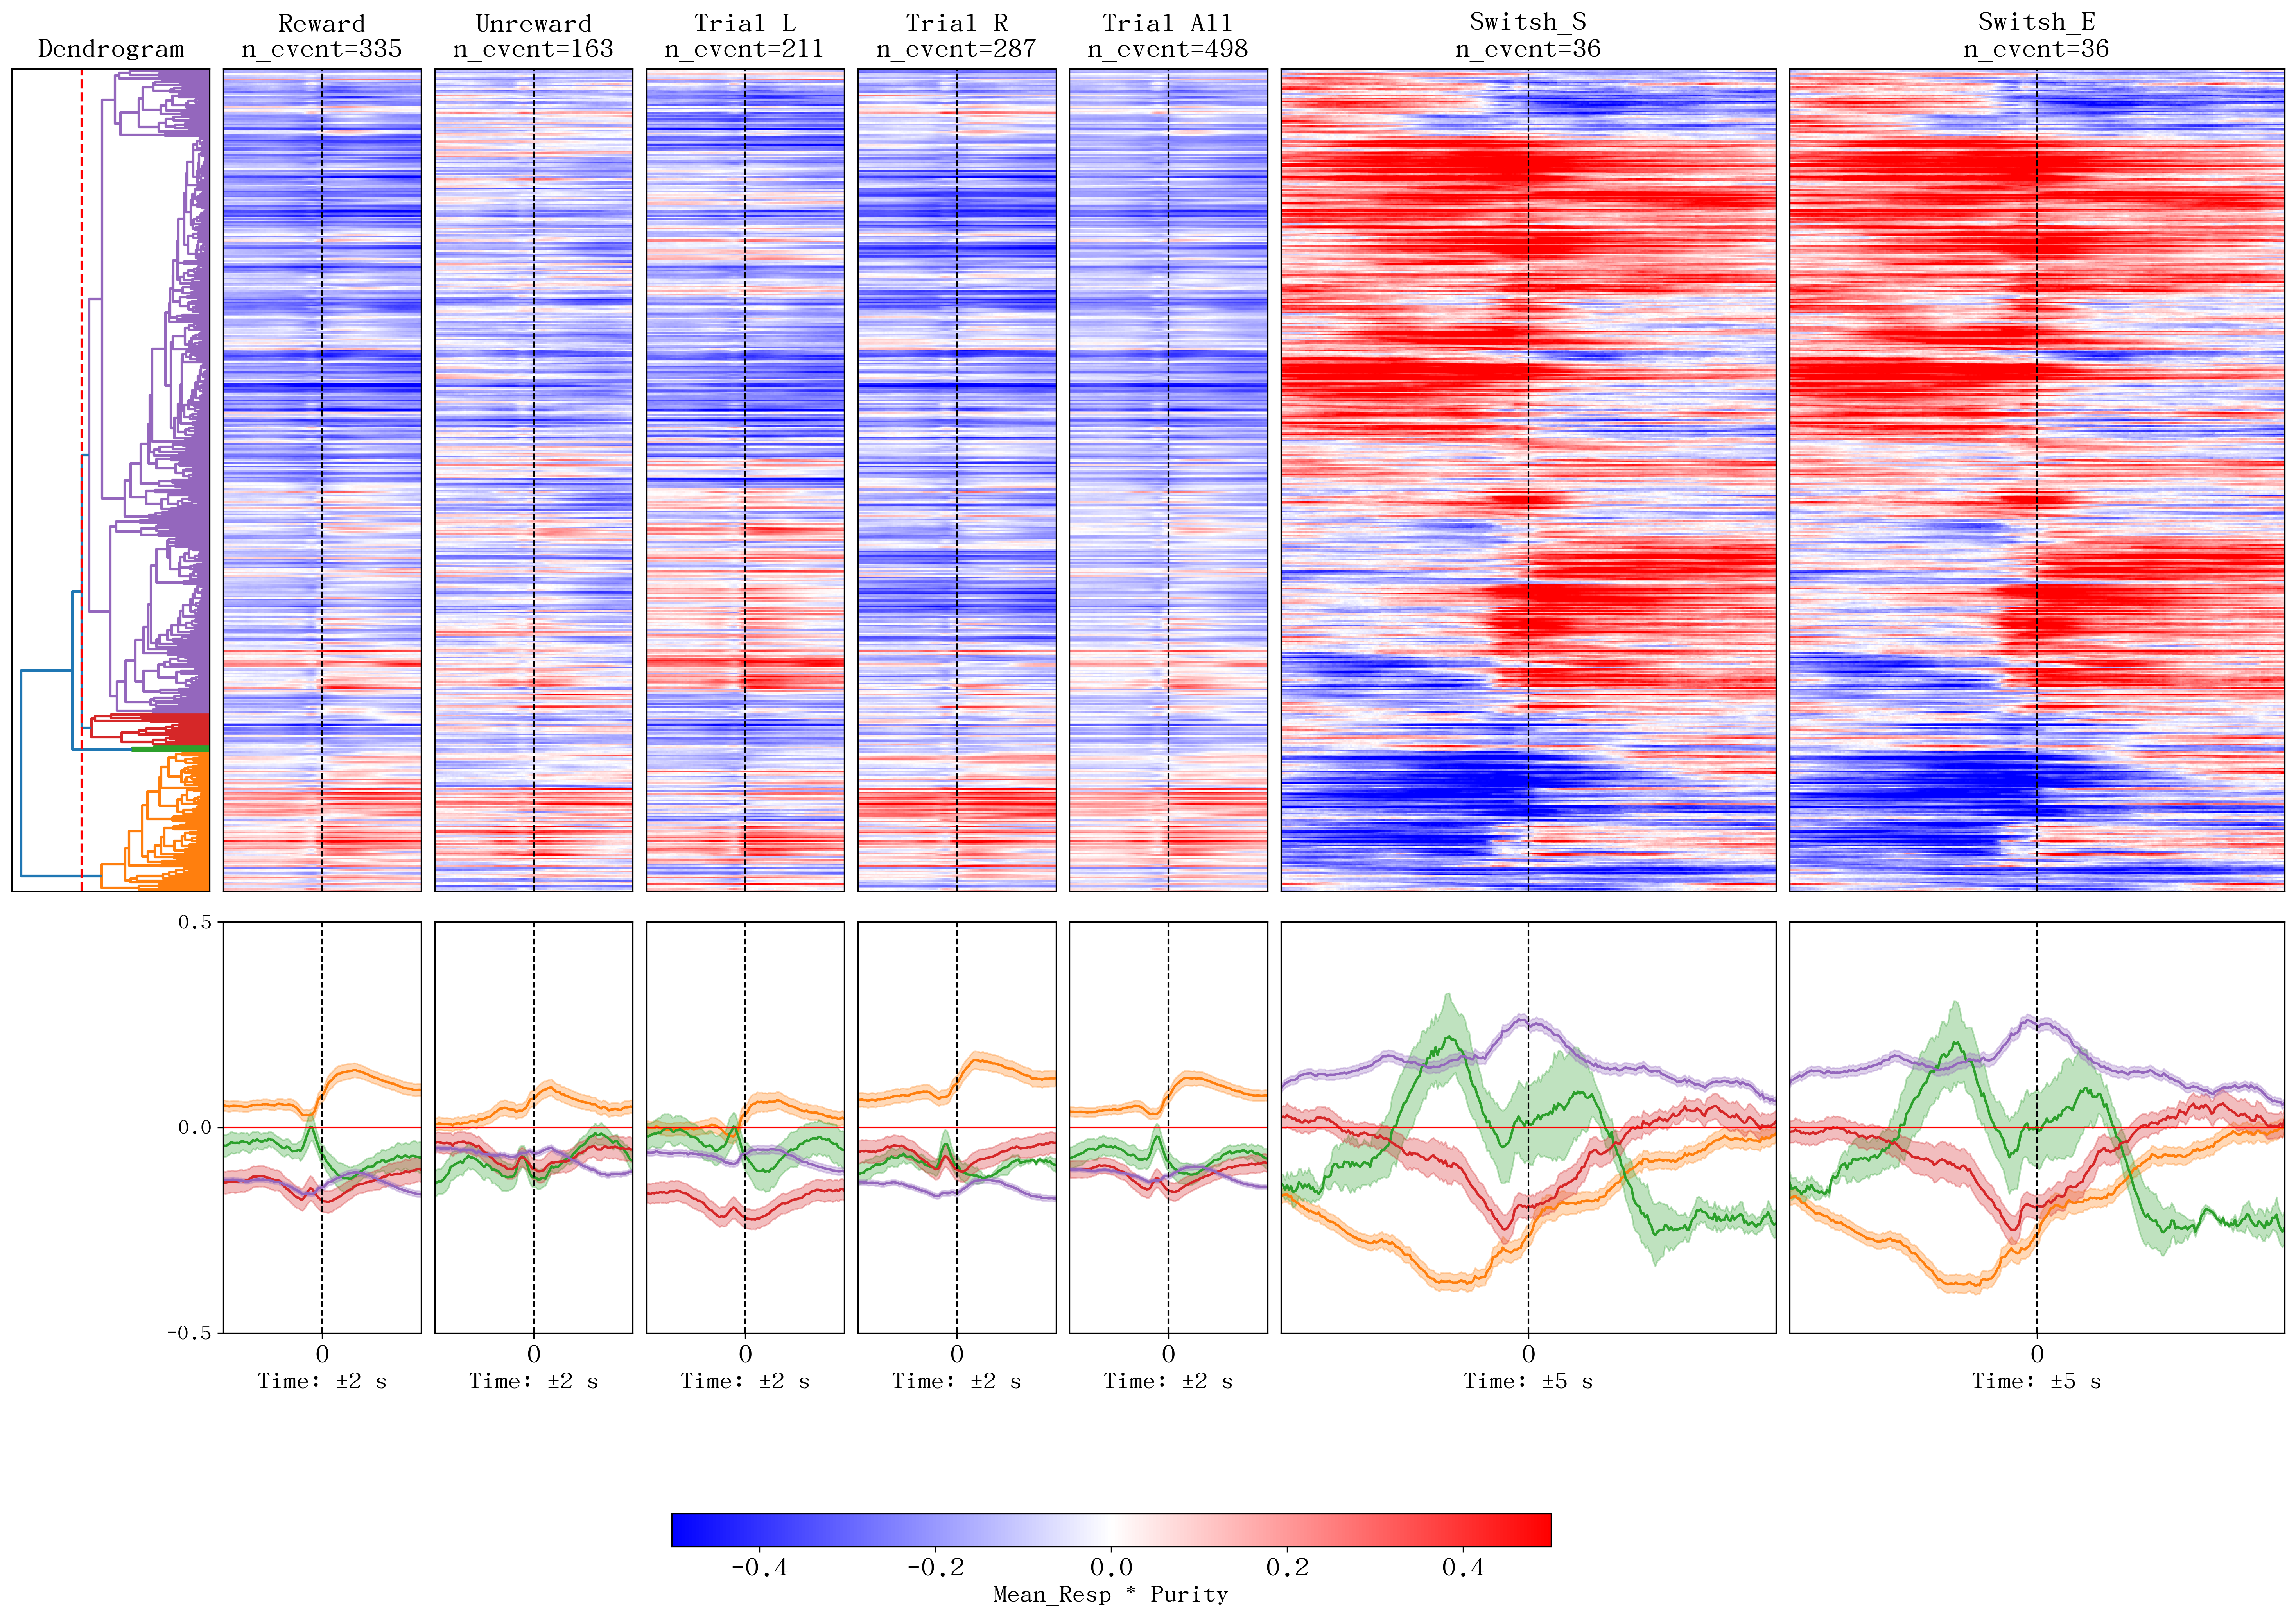

In [45]:
n_clusters = 4
use_pur = False

mix_data=[]
if use_pur:
    for (mat,pur) in zip(matrix_list_E,matrix_pur_list_E):
        mix_data.append(mat*pur)
        
    for (mat,pur) in zip(matrix_list_S,matrix_pur_list_S):
        mix_data.append(mat*pur)
else:
    for mat in matrix_list_E:
        mix_data.append(mat)
        
    for mat in matrix_list_S:
        mix_data.append(mat)
    
tot_mix_data = np.concatenate(mix_data, axis=1)
features, sorted_idx,cluster,Z=cluster_matrix_hierarchical(tot_mix_data,max_features=20,n_clusters=n_clusters,metric='correlation',linkage_method='average')


titles = ["Reward", "Unreward", "Trial L", "Trial R", "Trial All","Switsh_S", "Switsh_E"]
lens=[2,2,2,2,2,5,5]
width_r=[1,1,1,1,1,2.5,2.5]

plt.rcParams.update({
    'font.size': 16,         # 所有字体的默认大小
    'axes.titlesize': 18,    # 子图标题大小
    'axes.labelsize': 16,    # 坐标轴标签字体
    'xtick.labelsize': 18,   # x 轴刻度字体
    'ytick.labelsize': 14,   # y 轴刻度字体
    'legend.fontsize': 14,   # 图例字体
    'figure.titlesize': 20   # 整体大标题字体
})



# ========== 构建 Figure ==========
fig = plt.figure(figsize=(25, 14), dpi=300)
gs = gridspec.GridSpec(2, 8, height_ratios=[2, 1], width_ratios=[1]+width_r, wspace=0.05, hspace=0.05)

# ========== 上方：dendrogram 和 heatmap ==========
last_merge_distances = sorted(Z[:, 2], reverse=True)  # 所有合并距离（降序）
cut_height = last_merge_distances[features[0] - 2]     # 直接取第n_clusters-1大的距离

ax_dendro = plt.subplot(gs[0, 0])
axes_heat = [plt.subplot(gs[0, i+1]) for i in range(7)]

dendro_data = dendrogram(
    Z,
    ax=ax_dendro,
    orientation='left',
    color_threshold=cut_height,
    no_labels=True
)
ax_dendro.axvline(x=cut_height, color='r', linestyle='--', linewidth=1.5,)
ax_dendro.set_xticks([])
ax_dendro.set_yticks([])
ax_dendro.set_title('Dendrogram')
# ========== 分配标签 ==========
labels = fcluster(Z, features[0], criterion='maxclust')  # 每个神经元所属簇
sorted_idx = dendro_data['leaves'][::-1]  # 已排序的神经元索引

from collections import defaultdict

cluster_colors = defaultdict(lambda: 'gray')
leaves = dendro_data['leaves']        # 序号排序
leaves_colors = dendro_data['leaves_color_list']  # 每个leaf的颜色

# 构建 cluster_id -> color 的映射
for idx, leaf in enumerate(leaves):
    cluster_id = cluster[leaf]
    if cluster_id not in cluster_colors:
        cluster_colors[cluster_id] = leaves_colors[idx]

for i, (matrix, ax) in enumerate(zip(mix_data, axes_heat)):
    im = ax.imshow(matrix[sorted_idx], cmap='bwr', vmin=-0.5, vmax=0.5, aspect='auto')
    ax.axvline(x=matrix.shape[1]//2, color='k', linestyle='--', linewidth=1)
    ax.set_yticks([])
    ax.set_title(titles[i]+f'\nn_event={len(trigger_list[i])}')
    ax.set_xticks([])


# ========== 下方：每个簇的平均响应 ± SEM ==========
axes_avg = [plt.subplot(gs[1, i+1]) for i in range(7)]

for i, (matrix, ax) in enumerate(zip(mix_data, axes_avg)):
    x = np.linspace(-lens[i], lens[i], matrix.shape[1])
    for cluster_id in range(1, features[0]+1):
        cluster_idx = np.where(labels == cluster_id)[0]
        mean_trace = matrix[cluster_idx].mean(axis=0)
        error = sem(matrix[cluster_idx], axis=0)

        ax.plot(x, mean_trace, label=f'Cluster {cluster_id}', color=cluster_colors[cluster_id])
        ax.fill_between(x, mean_trace-error, mean_trace+error, color=cluster_colors[cluster_id], alpha=0.3)
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=1)
    ax.set_yticks([])
    ax.set_xlabel(f'Time: ±{lens[i]} s')
    ax.set_xticks([(x[0]+x[-1])/2])
    ax.set_xticklabels([0])
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(-0.5, 0.5)
    ax.axhline(y=0, color='red', linewidth=1)
axes_avg[0].set_yticks([-0.5,0,0.5])
plt.tight_layout(rect=[0, 0, 1, 1], pad=0.5)
cbar_ax = fig.add_axes([0.35, -0.02, 0.3, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Mean_Resp * Purity')
plt.show()

[0.48216982 0.2813725  0.12996593 0.05185472 0.02142503]


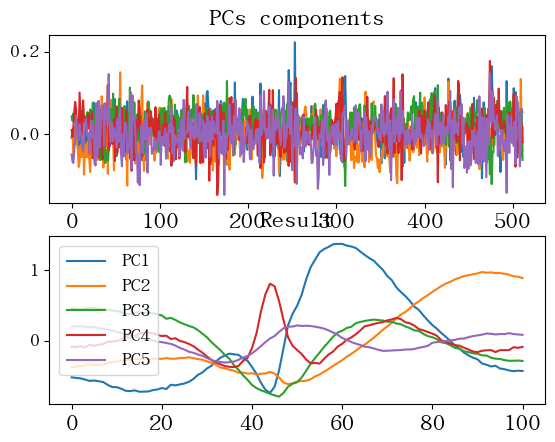

In [46]:
#对matrix_list_E[4]进行PCA降维
from sklearn.decomposition import PCA
trial_data = matrix_list_E[4]# nCell*T

pca = PCA(n_components=5)
pca.fit(trial_data.T)
pca_result = pca.transform(trial_data.T)
# 查看主成分
plt.subplot(2,1,1)
plt.plot(pca.components_.T)
plt.title('PCs components')
plt.subplot(2,1,2)
plt.plot(pca_result)
plt.title('Result')
plt.legend(['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
print(pca.explained_variance_ratio_)

# 获取时间点的 PC1 方向（在细胞空间中的方向）
trial_pc1_direction = pca.components_[0]  # shape: (nCell,)

# 1. 投影时间点到 PC1 轴
trial_scores_pc1 = pca.transform(trial_data.T)[:, 0]  # shape: (T,)

# 2. 投影到与 PC1 正交的空间（去除 PC1 影响的时间点数据）
n_features =  trial_data.shape[0]  # nCell
projection_matrix = np.eye(n_features) - np.outer(trial_pc1_direction, trial_pc1_direction)
trial_projection = trial_data.T @ projection_matrix  # shape: (T, nCell)

数据统计: L=211, R=287, Rew=335, ROm=163
nCell=512, nT=101

解码模式: NoProjection (不去除PC1，直接独立解码)

[Step 1] 解码 Left vs Right (原始数据，无投影)
  LR 准确率: 97.78% ± 1.48%
  分时间窗口:
    full: 86.46% ± 3.65%
    preparing: 72.73% ± 3.56%
    acting: 67.47% ± 4.75%
    response: 72.73% ± 4.24%

[Step 2] 解码 Rew vs ROm (原始数据，无投影)
  Rew 准确率: 81.62% ± 1.74%
  分时间窗口:
    full: 77.37% ± 2.44%
    preparing: 68.28% ± 3.17%
    acting: 67.27% ± 2.44%
    response: 67.88% ± 1.34%


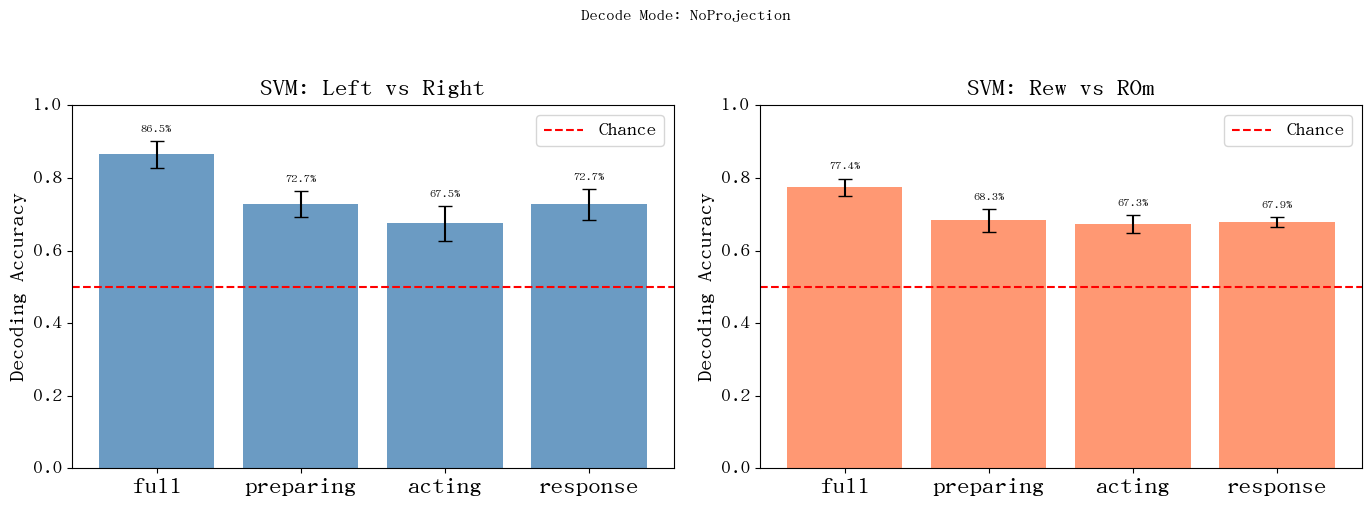

In [47]:
# ========== SVM 解码分析 (可切换解码模式) ==========
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# ==================== 配置 ====================
# 'LR_then_Rew': 去除PC1 -> 先解码LR -> 二次剔除 -> 解码Rew
# 'Rew_then_LR': 去除PC1 -> 先解码Rew -> 二次剔除 -> 解码LR
# 'NoProjection': 不去除PC1，直接分别解码Rew和LR（独立解码）
DECODE_MODE = 'NoProjection'

# 时间窗口定义
TIME_WINDOWS = {
    'full': (0, 101),
    'preparing': (0, 40),
    'acting': (40, 61),
    'response': (61, 101),
}

# ==================== 辅助函数 ====================
def extract_trials(trigger_list, signal, window=(-50, 51)):
    """提取每个trial的神经活动数据"""
    react_list = []
    for i in trigger_list:
        crop_data = np.array(signal[:, max(i + window[0], 0):min(i + window[1], signal.shape[1])])
        if crop_data.shape[1] == window[1] - window[0]:
            react_list.append(crop_data)
    return np.stack(react_list) if react_list else None

def apply_projection_per_timepoint(data_3D, proj_matrix):
    """对3D数据 (nTrial, nCell, T) 的每个时间点分别应用投影"""
    nTrial, nCell, nT = data_3D.shape
    data_transposed = data_3D.transpose(0, 2, 1)  # (nTrial, T, nCell)
    data_proj_list = []
    for t in range(nT):
        proj_t = data_transposed[:, t, :] @ proj_matrix  # (nTrial, nCell)
        data_proj_list.append(proj_t)
    data_proj = np.stack(data_proj_list, axis=1)  # (nTrial, T, nCell)
    return data_proj.transpose(0, 2, 1)  # (nTrial, nCell, T)

def run_svm_decoding(X, y, cv):
    """运行SVM解码并返回交叉验证分数"""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    svm = SVC(kernel='linear', C=1.0)
    svm.fit(X_scaled, y)
    scores = cross_val_score(svm, X_scaled, y, cv=cv, scoring='accuracy')
    return scores, svm

def get_proj_matrix_flat(w, nCell, nT):
    """从展平权重向量获取投影矩阵"""
    w_2D = w.reshape(nCell, nT)
    w_avg = w_2D.mean(axis=1)  # (nCell,)
    w_norm = w_avg / np.linalg.norm(w_avg)
    return np.eye(nCell) - np.outer(w_norm, w_norm)

def decode_by_window(data_dict, cv, time_windows, nCell):
    """分时间窗口解码"""
    results = {}
    for name, (start, end) in time_windows.items():
        X_list, y_list = [], []
        for label, (data_3D, y_label) in data_dict.items():
            win_data = data_3D[:, start:end, :]
            X_list.append(win_data.reshape(win_data.shape[0], -1))
            y_list.append(np.full(win_data.shape[0], y_label))
        X = np.vstack(X_list)
        y = np.concatenate(y_list)
        scores, _ = run_svm_decoding(X, y, cv)
        results[name] = {'mean': scores.mean(), 'std': scores.std()}
    return results

# ==================== 准备数据 ====================
trigger_left = trigger_TL   # SlnL + ROmL (左侧)
trigger_right = trigger_TR   # SlnR + ROmR (右侧)
trigger_rew = trigger_Rew   # SlnL + SlnR (Reward)
trigger_rom = trigger_Rom   # ROmL + ROmR (Unreward)

print(f"数据统计: L={len(trigger_left)}, R={len(trigger_right)}, Rew={len(trigger_rew)}, ROm={len(trigger_rom)}")

# 提取原始trial数据
left_raw = extract_trials(trigger_left, signal)    # (n_L, nCell, 101)
right_raw = extract_trials(trigger_right, signal)   # (n_R, nCell, 101)
rew_raw = extract_trials(trigger_rew, signal)       # (n_Rew, nCell, 101)
rom_raw = extract_trials(trigger_rom, signal)       # (n_ROm, nCell, 101)

nCell = left_raw.shape[1]
nT = left_raw.shape[2]
print(f"nCell={nCell}, nT={nT}")

# 应用PC1投影 (对每个时间点分别应用)
left_pc1 = apply_projection_per_timepoint(left_raw, projection_matrix)
right_pc1 = apply_projection_per_timepoint(right_raw, projection_matrix)
rew_pc1 = apply_projection_per_timepoint(rew_raw, projection_matrix)
rom_pc1 = apply_projection_per_timepoint(rom_raw, projection_matrix)

# ==================== 解码分析 ====================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_lr = {}
results_rew = {}
w_lr = None
w_rew = None

if DECODE_MODE == 'NoProjection':
    print("\n" + "="*50)
    print("解码模式: NoProjection (不去除PC1，直接独立解码)")
    print("="*50)
    
    # 直接解码 Left vs Right (原始数据，不用投影)
    print("\n[Step 1] 解码 Left vs Right (原始数据，无投影)")
    X_lr = np.vstack([left_raw.reshape(left_raw.shape[0], -1), 
                      right_raw.reshape(right_raw.shape[0], -1)])
    y_lr = np.array([0]*len(left_raw) + [1]*len(right_raw))
    scores_lr, svm_lr = run_svm_decoding(X_lr, y_lr, cv)
    w_lr = svm_lr.coef_.flatten()
    
    print(f"  LR 准确率: {scores_lr.mean():.2%} ± {scores_lr.std():.2%}")
    
    # 分时间窗口
    results_lr = decode_by_window({'Left': (left_raw, 0), 'Right': (right_raw, 1)}, cv, TIME_WINDOWS, nCell)
    print("  分时间窗口:")
    for w_name, w_res in results_lr.items():
        print(f"    {w_name}: {w_res['mean']:.2%} ± {w_res['std']:.2%}")
    
    # 直接解码 Rew vs ROm (原始数据，不用投影)
    print("\n[Step 2] 解码 Rew vs ROm (原始数据，无投影)")
    X_rew = np.vstack([rew_raw.reshape(rew_raw.shape[0], -1),
                       rom_raw.reshape(rom_raw.shape[0], -1)])
    y_rew = np.array([0]*len(rew_raw) + [1]*len(rom_raw))
    scores_rew, svm_rew = run_svm_decoding(X_rew, y_rew, cv)
    w_rew = svm_rew.coef_.flatten()
    
    print(f"  Rew 准确率: {scores_rew.mean():.2%} ± {scores_rew.std():.2%}")
    
    # 分时间窗口
    results_rew = decode_by_window({'Rew': (rew_raw, 0), 'ROm': (rom_raw, 1)}, cv, TIME_WINDOWS, nCell)
    print("  分时间窗口:")
    for w_name, w_res in results_rew.items():
        print(f"    {w_name}: {w_res['mean']:.2%} ± {w_res['std']:.2%}")

elif DECODE_MODE == 'LR_then_Rew':
    print("\n" + "="*50)
    print("解码模式: LR_then_Rew (去除PC1 -> 先解码LR -> 二次剔除 -> 解码Rew)")
    print("="*50)
    
    # Step 1: 解码 Left vs Right
    print("\n[Step 1] 解码 Left vs Right (去除PC1后)")
    X_lr = np.vstack([left_pc1.reshape(left_pc1.shape[0], -1), 
                      right_pc1.reshape(right_pc1.shape[0], -1)])
    y_lr = np.array([0]*len(left_pc1) + [1]*len(right_pc1))
    scores_lr, svm_lr = run_svm_decoding(X_lr, y_lr, cv)
    w_lr = svm_lr.coef_.flatten()
    
    print(f"  LR 准确率: {scores_lr.mean():.2%} ± {scores_lr.std():.2%}")
    
    proj_lr = get_proj_matrix_flat(w_lr, nCell, nT)
    
    results_lr = decode_by_window({'Left': (left_pc1, 0), 'Right': (right_pc1, 1)}, cv, TIME_WINDOWS, nCell)
    print("  分时间窗口:")
    for w_name, w_res in results_lr.items():
        print(f"    {w_name}: {w_res['mean']:.2%} ± {w_res['std']:.2%}")
    
    # Step 2: 解码 Rew vs ROm (去除PC1 + SVM_LR后)
    print("\n[Step 2] 解码 Rew vs ROm (去除PC1 + SVM_LR后)")
    rew_no_lr = apply_projection_per_timepoint(rew_raw, proj_lr)
    rom_no_lr = apply_projection_per_timepoint(rom_raw, proj_lr)
    
    X_rew = np.vstack([rew_no_lr.reshape(rew_no_lr.shape[0], -1),
                       rom_no_lr.reshape(rom_no_lr.shape[0], -1)])
    y_rew = np.array([0]*len(rew_no_lr) + [1]*len(rom_no_lr))
    scores_rew, _ = run_svm_decoding(X_rew, y_rew, cv)
    print(f"  Rew 准确率: {scores_rew.mean():.2%} ± {scores_rew.std():.2%}")
    
    results_rew = decode_by_window({'Rew': (rew_no_lr, 0), 'ROm': (rom_no_lr, 1)}, cv, TIME_WINDOWS, nCell)
    print("  分时间窗口:")
    for w_name, w_res in results_rew.items():
        print(f"    {w_name}: {w_res['mean']:.2%} ± {w_res['std']:.2%}")

else:  # Rew_then_LR
    print("\n" + "="*50)
    print("解码模式: Rew_then_LR (去除PC1 -> 先解码Rew -> 二次剔除 -> 解码LR)")
    print("="*50)
    
    # Step 1: 解码 Rew vs ROm
    print("\n[Step 1] 解码 Rew vs ROm (去除PC1后)")
    X_rew = np.vstack([rew_pc1.reshape(rew_pc1.shape[0], -1),
                       rom_pc1.reshape(rom_pc1.shape[0], -1)])
    y_rew = np.array([0]*len(rew_pc1) + [1]*len(rom_pc1))
    scores_rew, svm_rew = run_svm_decoding(X_rew, y_rew, cv)
    w_rew = svm_rew.coef_.flatten()
    
    print(f"  Rew 准确率: {scores_rew.mean():.2%} ± {scores_rew.std():.2%}")
    
    proj_rew = get_proj_matrix_flat(w_rew, nCell, nT)
    
    results_rew = decode_by_window({'Rew': (rew_pc1, 0), 'ROm': (rom_pc1, 1)}, cv, TIME_WINDOWS, nCell)
    print("  分时间窗口:")
    for w_name, w_res in results_rew.items():
        print(f"    {w_name}: {w_res['mean']:.2%} ± {w_res['std']:.2%}")
    
    # Step 2: 解码 Left vs Right (去除PC1 + SVM_Rew后)
    print("\n[Step 2] 解码 Left vs Right (去除PC1 + SVM_Rew后)")
    left_no_rew = apply_projection_per_timepoint(left_raw, proj_rew)
    right_no_rew = apply_projection_per_timepoint(right_raw, proj_rew)
    
    X_lr = np.vstack([left_no_rew.reshape(left_no_rew.shape[0], -1),
                      right_no_rew.reshape(right_no_rew.shape[0], -1)])
    y_lr = np.array([0]*len(left_no_rew) + [1]*len(right_no_rew))
    scores_lr, _ = run_svm_decoding(X_lr, y_lr, cv)
    print(f"  LR 准确率: {scores_lr.mean():.2%} ± {scores_lr.std():.2%}")
    
    results_lr = decode_by_window({'Left': (left_no_rew, 0), 'Right': (right_no_rew, 1)}, cv, TIME_WINDOWS, nCell)
    print("  分时间窗口:")
    for w_name, w_res in results_lr.items():
        print(f"    {w_name}: {w_res['mean']:.2%} ± {w_res['std']:.2%}")

# ==================== 可视化 ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, title, color in [
    (axes[0], results_lr, 'Left vs Right', 'steelblue'),
    (axes[1], results_rew, 'Rew vs ROm', 'coral')
]:
    names = list(results.keys())
    means = [results[n]['mean'] for n in names]
    stds = [results[n]['std'] for n in names]
    x_pos = np.arange(len(names))
    
    bars = ax.bar(x_pos, means, yerr=stds, capsize=5, color=color, alpha=0.8)
    ax.axhline(y=0.5, color='red', linestyle='--', label='Chance')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(names)
    ax.set_ylabel('Decoding Accuracy')
    ax.set_title(f'SVM: {title}')
    ax.set_ylim(0, 1)
    ax.legend()
    
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.02, 
                f'{mean:.1%}', ha='center', va='bottom', fontsize=9)

plt.suptitle(f'Decode Mode: {DECODE_MODE}', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

w_lr shape: (7878,)
w_rew shape: (7878,)
importance_scores shape: (78,)
trial_pc1_direction shape: (78,)
nT: 101
nCell_total: 78, nT_from_svm: 101

After processing:
pos_direction shape: (78,)
pc1_direction shape: (78,)
w_lr_direction shape: (78,)
w_rew_direction shape: (78,)


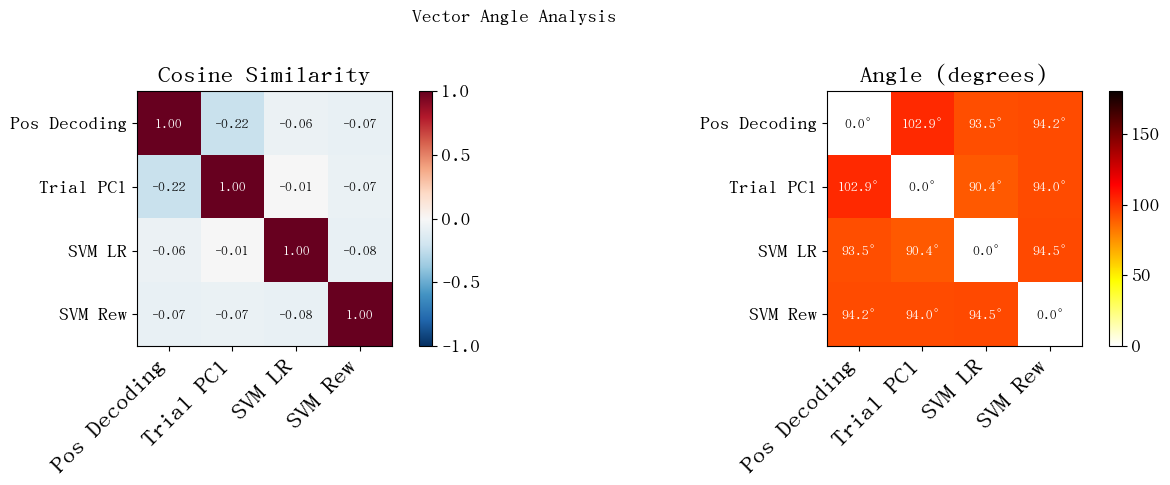


向量夹角分析结果 (度)
                   Pos Dec  Trial PC1     SVM LR    SVM Rew
   Pos Decoding        0.0°      102.9°       93.5°       94.2°
      Trial PC1      102.9°        0.0°       90.4°       94.0°
         SVM LR       93.5°       90.4°        0.0°       94.5°
        SVM Rew       94.2°       94.0°       94.5°        0.0°


In [28]:
# ========== 向量夹角分析 ==========
# 直接使用已有的变量: trial_pc1_direction, w_lr, w_rew, importance_scores

# 打印形状确认
print(f"w_lr shape: {w_lr.shape}")
print(f"w_rew shape: {w_rew.shape}")
print(f"importance_scores shape: {importance_scores.shape}")
print(f"trial_pc1_direction shape: {trial_pc1_direction.shape}")
print(f"nT: {nT}")

# w_lr 和 w_rew 是 (nCell * nT,) 的扁平向量
nCell_total = importance_scores.shape[0]
nT_from_svm = w_lr.shape[0] // nCell_total
print(f"nCell_total: {nCell_total}, nT_from_svm: {nT_from_svm}")

# 1. 位置解码贡献向量: 直接用 Leave-One-Out importance_scores 作为细胞权重
pos_direction = importance_scores.copy()  # (nCell,)
pos_direction = pos_direction / np.linalg.norm(pos_direction)

# 2. Trial PC1 方向 (已有变量)
pc1_direction = trial_pc1_direction.copy()
if pc1_direction.shape[0] != nCell_total:
    pc1_direction = pc1_direction[:nCell_total]
pc1_direction = pc1_direction / np.linalg.norm(pc1_direction)

# 3. SVM LR 决策向量: w_lr (nCell*nT,) -> 时间平均
w_lr_2D = w_lr.reshape(nCell_total, nT_from_svm)  # 正确reshape
w_lr_avg = w_lr_2D.mean(axis=1)  # (nCell,)
w_lr_direction = w_lr_avg / np.linalg.norm(w_lr_avg)

# 4. SVM Rew 决策向量: w_rew (nCell*nT,) -> 时间平均
w_rew_2D = w_rew.reshape(nCell_total, nT_from_svm)  # 正确reshape
w_rew_avg = w_rew_2D.mean(axis=1)  # (nCell,)
w_rew_direction = w_rew_avg / np.linalg.norm(w_rew_avg)

print(f"\nAfter processing:")
print(f"pos_direction shape: {pos_direction.shape}")
print(f"pc1_direction shape: {pc1_direction.shape}")
print(f"w_lr_direction shape: {w_lr_direction.shape}")
print(f"w_rew_direction shape: {w_rew_direction.shape}")

# ========== 计算余弦相似度矩阵 ==========
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

vectors = {
    'Pos Decoding': pos_direction,
    'Trial PC1': pc1_direction,
    'SVM LR': w_lr_direction,
    'SVM Rew': w_rew_direction,
}

vector_names = list(vectors.keys())
n = len(vector_names)
cosine_matrix = np.zeros((n, n))
angle_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        cosine_matrix[i, j] = cosine_similarity(vectors[vector_names[i]], vectors[vector_names[j]])
        angle_matrix[i, j] = np.arccos(np.clip(cosine_matrix[i, j], -1, 1)) * 180 / np.pi

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 余弦相似度热图
ax1 = axes[0]
im1 = ax1.imshow(cosine_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax1.set_xticks(range(n))
ax1.set_yticks(range(n))
ax1.set_xticklabels(vector_names, rotation=45, ha='right')
ax1.set_yticklabels(vector_names)
ax1.set_title('Cosine Similarity')
for i in range(n):
    for j in range(n):
        ax1.text(j, i, f'{cosine_matrix[i, j]:.2f}', ha='center', va='center', 
                color='white' if abs(cosine_matrix[i, j]) > 0.5 else 'black', fontsize=10)
plt.colorbar(im1, ax=ax1)

# 2. 角度热图 (度)
ax2 = axes[1]
im2 = ax2.imshow(angle_matrix, cmap='hot_r', vmin=0, vmax=180)
ax2.set_xticks(range(n))
ax2.set_yticks(range(n))
ax2.set_xticklabels(vector_names, rotation=45, ha='right')
ax2.set_yticklabels(vector_names)
ax2.set_title('Angle (degrees)')
for i in range(n):
    for j in range(n):
        ax2.text(j, i, f'{angle_matrix[i, j]:.1f}°', ha='center', va='center', 
                color='white' if angle_matrix[i, j] > 90 else 'black', fontsize=10)
plt.colorbar(im2, ax=ax2)

plt.suptitle('Vector Angle Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# 打印详细结果
print("\n" + "="*60)
print("向量夹角分析结果 (度)")
print("="*60)
print(f"{'':>15} {'Pos Dec':>10} {'Trial PC1':>10} {'SVM LR':>10} {'SVM Rew':>10}")
for i, name_i in enumerate(vector_names):
    row = f"{name_i:>15}"
    for j, name_j in enumerate(vector_names):
        row += f" {angle_matrix[i, j]:>10.1f}°"
    print(row)
print("="*60)